# Customer Shopping Trends & Basket Analysis

**Author:** Ibrahim  
**Environment:** Google Colab / Python 3

## Overview
This project analyses customer shopping behaviour to uncover trends in spending, category preferences, seasonal patterns, and the impact of discounts and subscriptions. The insights help retailers personalise marketing, optimise promotions, and manage inventory.

## Dataset
- **Source:** Kaggle – Customer Shopping Trends
- **Rows:** 3,900 transactions
- **Columns:** Customer ID, Age, Gender, Item Purchased, Category, Purchase Amount, Season, Discount Applied, Subscription Status, Shipping Type, Payment Method, etc.

## Key Steps
1. Load and clean data
2. Explore spending by category, season, demographics
3. Analyse discount and subscription effects
4. Identify top items and payment preferences
5. Visualise key relationships

## Requirements
- pandas, matplotlib, seaborn, numpy

---

**© 2026 Ibrahim – Retail customer analytics.**

### Install & Imports

In [17]:
!pip install -q pandas matplotlib seaborn

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

### Load Dataset

In [19]:
# Download from public URL (Kaggle raw CSV)
data = "/content/shopping_trends_updated.csv"
df = pd.read_csv(data)

print("Dataset shape:", df.shape)
df.head(2)

Dataset shape: (3900, 18)


,Customer ID,Age,Gender,Item Purchased,Category,Purchase Amount (USD),Location,Size,Color,Season,Review Rating,Subscription Status,Shipping Type,Discount Applied,Promo Code Used,Previous Purchases,Payment Method,Frequency of Purchases
0,1,55,Male,Blouse,Clothing,53,Kentucky,L,Gray,Winter,3.1,Yes,Express,Yes,Yes,14,Venmo,Fortnightly
1,2,19,Male,Sweater,Clothing,64,Maine,L,Maroon,Winter,3.1,Yes,Express,Yes,Yes,2,Cash,Fortnightly


### Data Cleaning & Preparation

In [20]:
# Check for missing values
print("Missing values:\n", df.isnull().sum())

# Ensure Purchase Amount is numeric
df['Purchase Amount (USD)'] = pd.to_numeric(df['Purchase Amount (USD)'], errors='coerce')

# Remove rows with missing critical fields
df_clean = df.dropna(subset=['Purchase Amount (USD)', 'Category', 'Age'])

# Create age groups
bins = [18, 25, 35, 45, 55, 70]
labels = ['18-24', '25-34', '35-44', '45-54', '55+']
df_clean['Age Group'] = pd.cut(df_clean['Age'], bins=bins, labels=labels, right=False)

print(f"Rows after cleaning: {len(df_clean)}")

Missing values:
 Customer ID               0
Age                       0
Gender                    0
Item Purchased            0
Category                  0
Purchase Amount (USD)     0
Location                  0
Size                      0
Color                     0
Season                    0
Review Rating             0
Subscription Status       0
Shipping Type             0
Discount Applied          0
Promo Code Used           0
Previous Purchases        0
Payment Method            0
Frequency of Purchases    0
dtype: int64
Rows after cleaning: 3900


### Purchase Amount Distribution

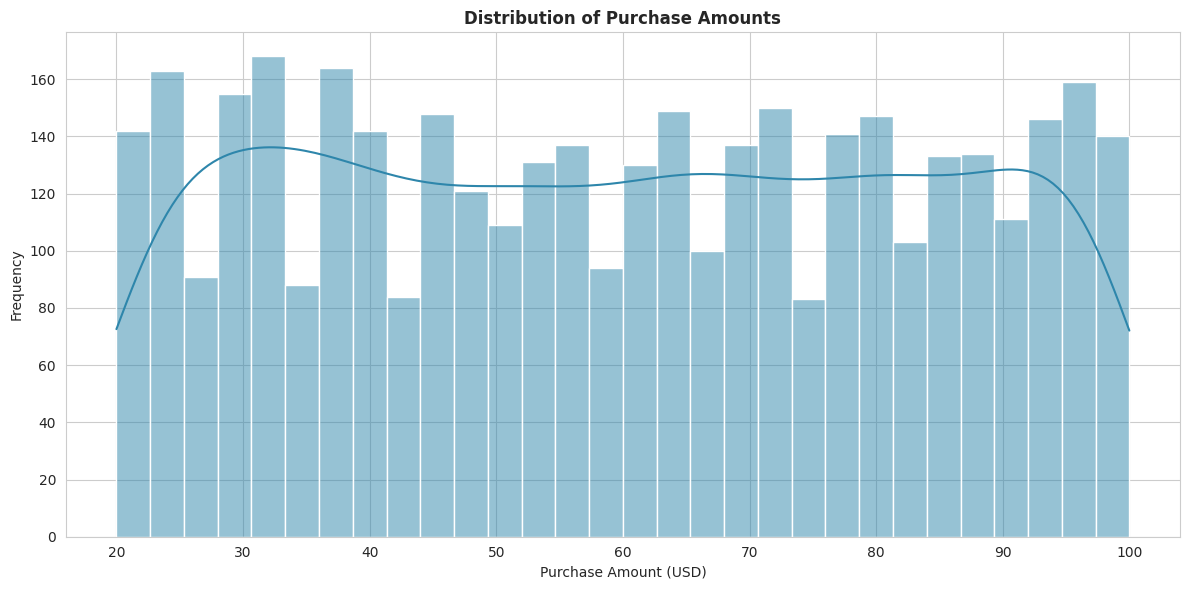

In [21]:
plt.figure(figsize=(12, 6))
sns.histplot(df_clean['Purchase Amount (USD)'], bins=30, kde=True, color='#2E86AB')
plt.xlabel('Purchase Amount (USD)')
plt.ylabel('Frequency')
plt.title('Distribution of Purchase Amounts', fontweight='bold')
plt.tight_layout()
plt.show()

### Average Purchase Amount by Category

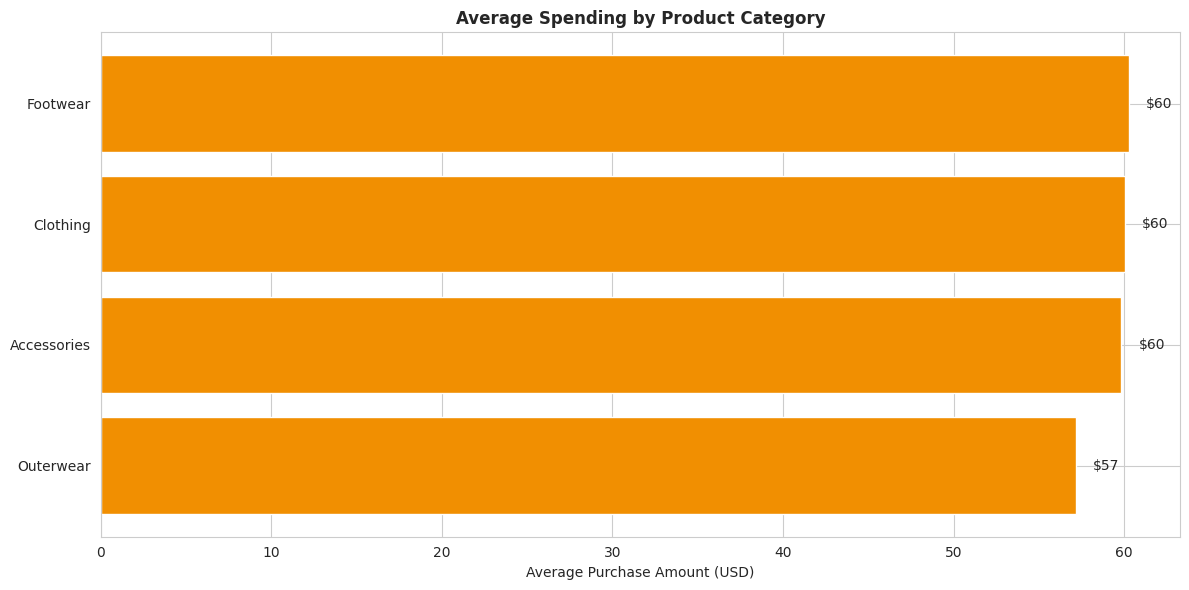

In [22]:
category_spend = df_clean.groupby('Category')['Purchase Amount (USD)'].mean().sort_values()

plt.figure(figsize=(12, 6))
bars = plt.barh(category_spend.index, category_spend.values, color='#F18F01')
plt.xlabel('Average Purchase Amount (USD)')
plt.title('Average Spending by Product Category', fontweight='bold')
for bar in bars:
    width = bar.get_width()
    plt.text(width + 1, bar.get_y() + bar.get_height()/2, f'${width:.0f}', va='center')
plt.tight_layout()
plt.show()

### Seasonal Spending Trends

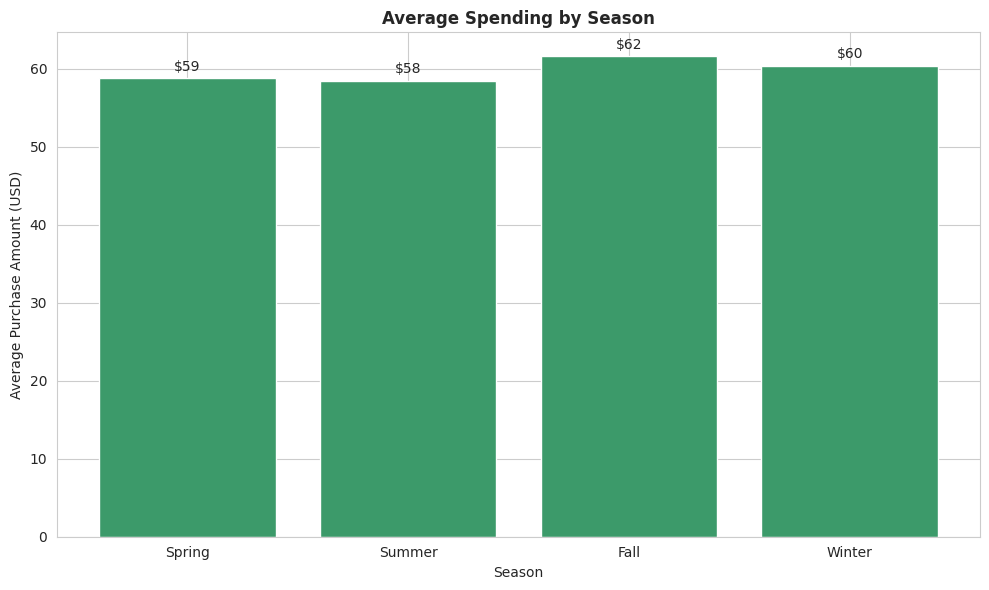

In [23]:
season_order = ['Spring', 'Summer', 'Fall', 'Winter']
seasonal_spend = df_clean.groupby('Season')['Purchase Amount (USD)'].mean().reindex(season_order)

plt.figure(figsize=(10, 6))
bars = plt.bar(seasonal_spend.index, seasonal_spend.values, color='#3C9A6A')
plt.xlabel('Season')
plt.ylabel('Average Purchase Amount (USD)')
plt.title('Average Spending by Season', fontweight='bold')
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, height + 1, f'${height:.0f}', ha='center')
plt.tight_layout()
plt.show()

### Gender vs Purchase Amount

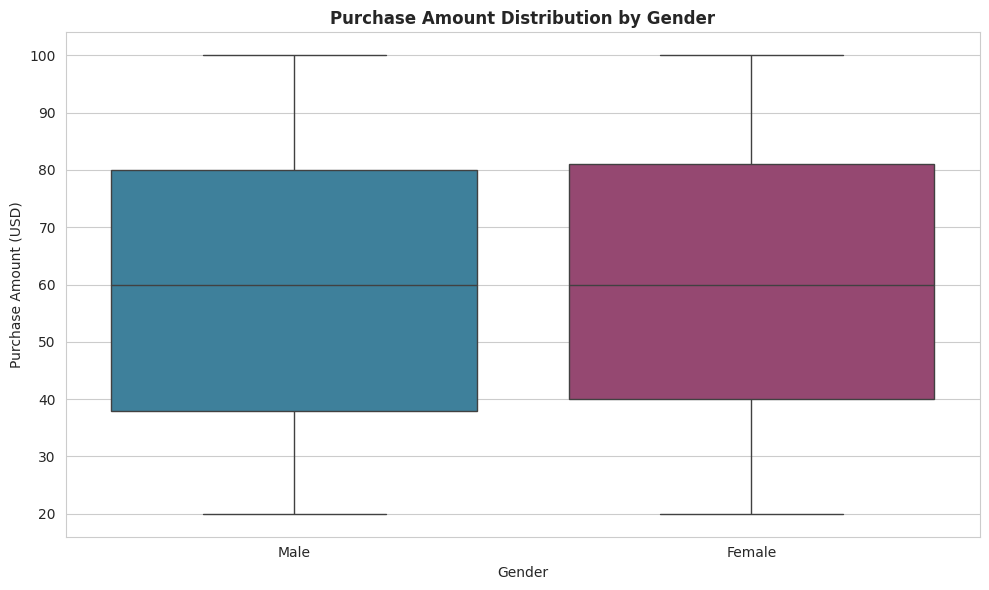

In [24]:
plt.figure(figsize=(10, 6))
sns.boxplot(data=df_clean, x='Gender', y='Purchase Amount (USD)', palette=['#2E86AB', '#A23B72'])
plt.ylabel('Purchase Amount (USD)')
plt.title('Purchase Amount Distribution by Gender', fontweight='bold')
plt.tight_layout()
plt.show()

### Age Group vs Purchase Amount

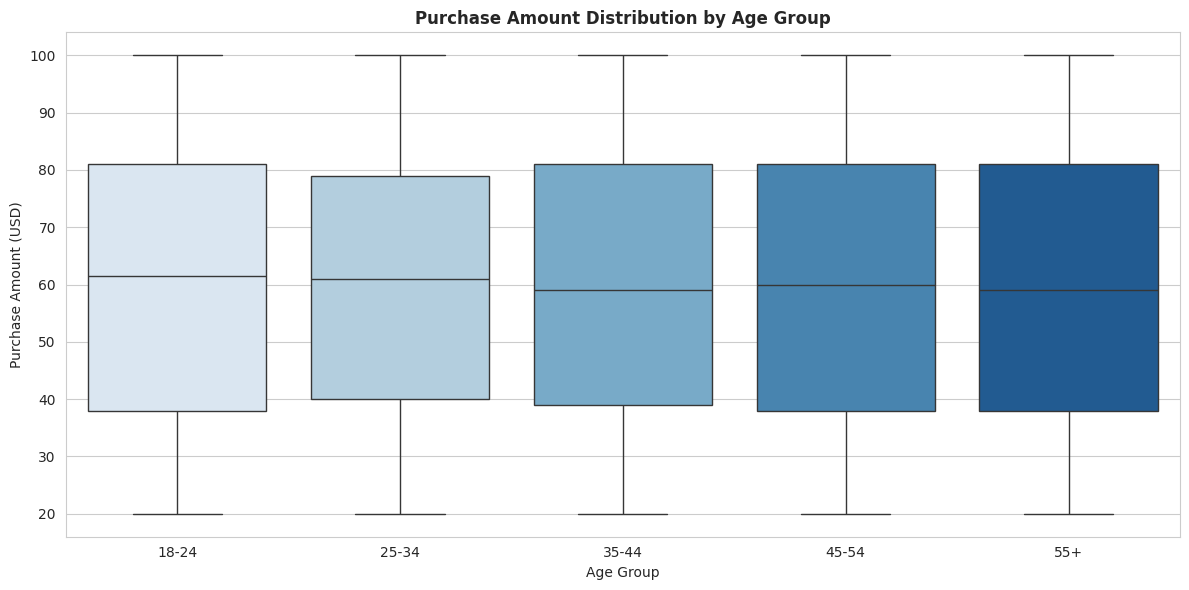

In [25]:
plt.figure(figsize=(12, 6))
sns.boxplot(data=df_clean, x='Age Group', y='Purchase Amount (USD)', palette='Blues')
plt.xlabel('Age Group')
plt.ylabel('Purchase Amount (USD)')
plt.title('Purchase Amount Distribution by Age Group', fontweight='bold')
plt.tight_layout()
plt.show()

### Discount vs Purchase Amount

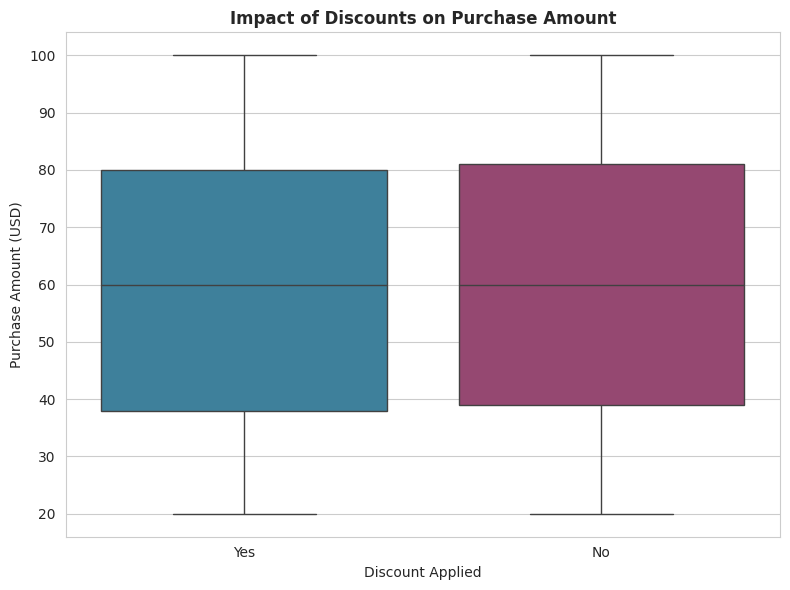

In [26]:
plt.figure(figsize=(8, 6))
sns.boxplot(data=df_clean, x='Discount Applied', y='Purchase Amount (USD)', palette=['#2E86AB', '#A23B72'])
plt.xlabel('Discount Applied')
plt.ylabel('Purchase Amount (USD)')
plt.title('Impact of Discounts on Purchase Amount', fontweight='bold')
plt.tight_layout()
plt.show()

### Subscription Status Impact

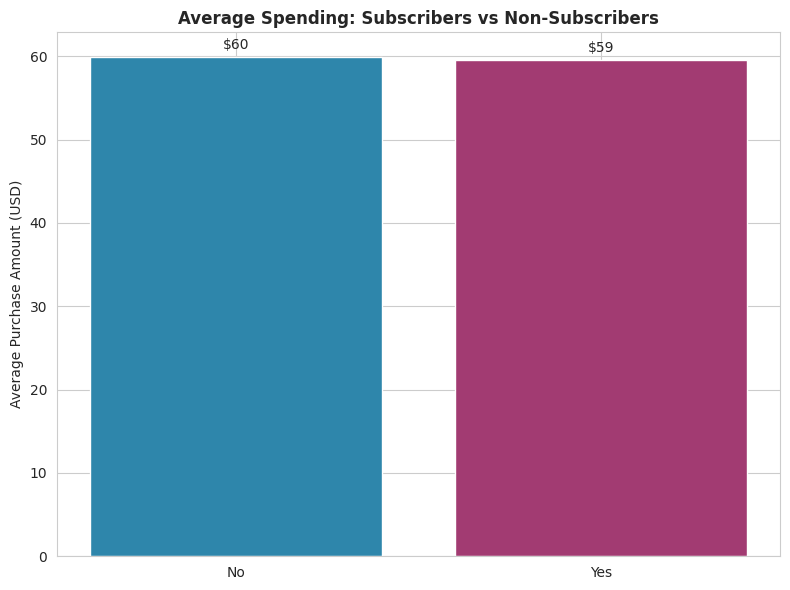

In [27]:
sub_spend = df_clean.groupby('Subscription Status')['Purchase Amount (USD)'].mean()

plt.figure(figsize=(8, 6))
bars = plt.bar(sub_spend.index, sub_spend.values, color=['#2E86AB', '#A23B72'])
plt.ylabel('Average Purchase Amount (USD)')
plt.title('Average Spending: Subscribers vs Non‑Subscribers', fontweight='bold')
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, height + 1, f'${height:.0f}', ha='center')
plt.tight_layout()
plt.show()

### Correlation Heatmap

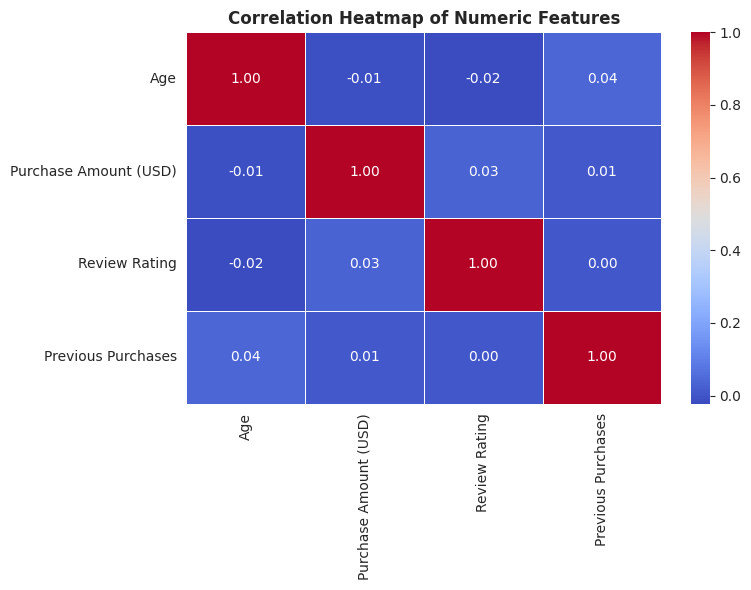

In [28]:
numeric_cols = ['Age', 'Purchase Amount (USD)', 'Review Rating', 'Previous Purchases']
corr = df_clean[numeric_cols].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Correlation Heatmap of Numeric Features', fontweight='bold')
plt.tight_layout()
plt.show()

### Top 10 Most Purchased Items

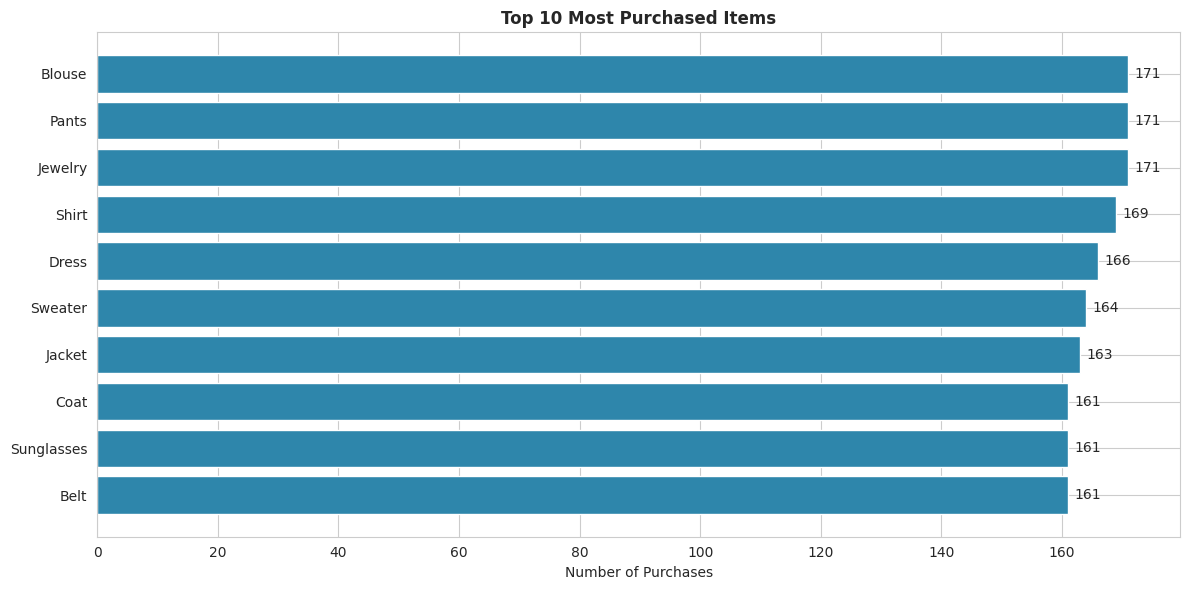

In [29]:
top_items = df_clean['Item Purchased'].value_counts().head(10)

plt.figure(figsize=(12, 6))
bars = plt.barh(top_items.index[::-1], top_items.values[::-1], color='#2E86AB')
plt.xlabel('Number of Purchases')
plt.title('Top 10 Most Purchased Items', fontweight='bold')
for bar in bars:
    width = bar.get_width()
    plt.text(width + 1, bar.get_y() + bar.get_height()/2, f'{int(width)}', va='center')
plt.tight_layout()
plt.show()

### Payment Method Preference

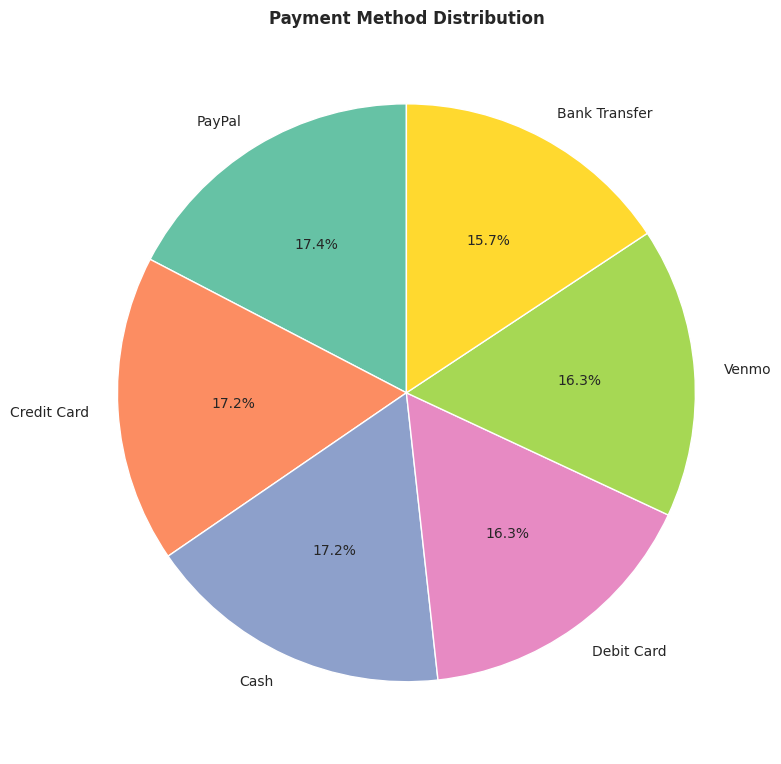

In [30]:
payment_counts = df_clean['Payment Method'].value_counts()

plt.figure(figsize=(8, 8))
plt.pie(payment_counts.values, labels=payment_counts.index, autopct='%1.1f%%', startangle=90, colors=plt.cm.Set2.colors)
plt.title('Payment Method Distribution', fontweight='bold')
plt.tight_layout()
plt.show()

### Key Insights Summary

In [31]:
print(" Key Insights from Customer Shopping Trends")
print(f" Total transactions analysed: {len(df_clean)}")
print(f" Average purchase amount: ${df_clean['Purchase Amount (USD)'].mean():.2f}")
print(f" Highest spending category: {category_spend.idxmax()} (${category_spend.max():.0f})")
print(f" Subscribers spend {sub_spend['Yes'] - sub_spend['No']:.0f} more than non‑subscribers")
print(f" Discount applied reduces average spend by ${df_clean[df_clean['Discount Applied']=='Yes']['Purchase Amount (USD)'].mean() - df_clean[df_clean['Discount Applied']=='No']['Purchase Amount (USD)'].mean():.0f}")
print(f"Most purchased item: {top_items.index[0]} ({top_items.iloc[0]} purchases)")

 Key Insights from Customer Shopping Trends
 Total transactions analysed: 3900
 Average purchase amount: $59.76
 Highest spending category: Footwear ($60)
 Subscribers spend -0 more than non‑subscribers
 Discount applied reduces average spend by $-1
Most purchased item: Blouse (171 purchases)


### Final Summary

In [32]:
print("Customer Shopping Trends Analysis - COMPLETED")
print("Author: Ibrahim")
print("Dataset cleaned and explored.")
print("Key drivers of spending identified.")
print("Insights for marketing and inventory planning ready.")

Customer Shopping Trends Analysis - COMPLETED
Author: Ibrahim
Dataset cleaned and explored.
Key drivers of spending identified.
Insights for marketing and inventory planning ready.
